In [8]:
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

load_dotenv()
xyz_val = pd.read_csv(os.path.join(os.getenv("music_dir"),r"XYZ/“Golden” Official Lyric Video ｜ KPop Demon Hunters ｜ Sony Animation.xyz"),sep=r'\s+',header=None, names=['x', 'y', 'z'])

In [9]:
def normalize(arr):
    min_val = np.min(arr)
    max_val = np.max(arr)
    if max_val == min_val:
        return np.zeros_like(arr)  # Prevent division by zero if all values are identical
    return (arr - min_val) / (max_val - min_val)
time = normalize(xyz_val["x"])
amp = normalize(xyz_val["y"])
freq = normalize(xyz_val["z"])

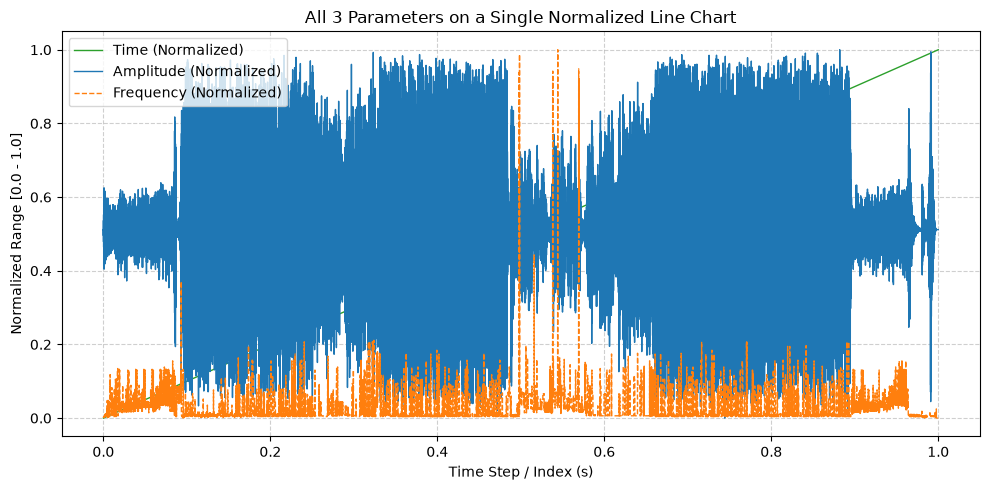

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(time, time, label='Time (Normalized)', color='#2ca02c', linewidth=1)
plt.plot(time, amp, label='Amplitude (Normalized)', color='#1f77b4', linewidth=1)
plt.plot(time, freq, label='Frequency (Normalized)', color='#ff7f0e', linewidth=1, linestyle='--')

plt.xlabel('Time Step / Index (s)')
plt.ylabel('Normalized Range [0.0 - 1.0]')
plt.title('All 3 Parameters on a Single Normalized Line Chart')
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

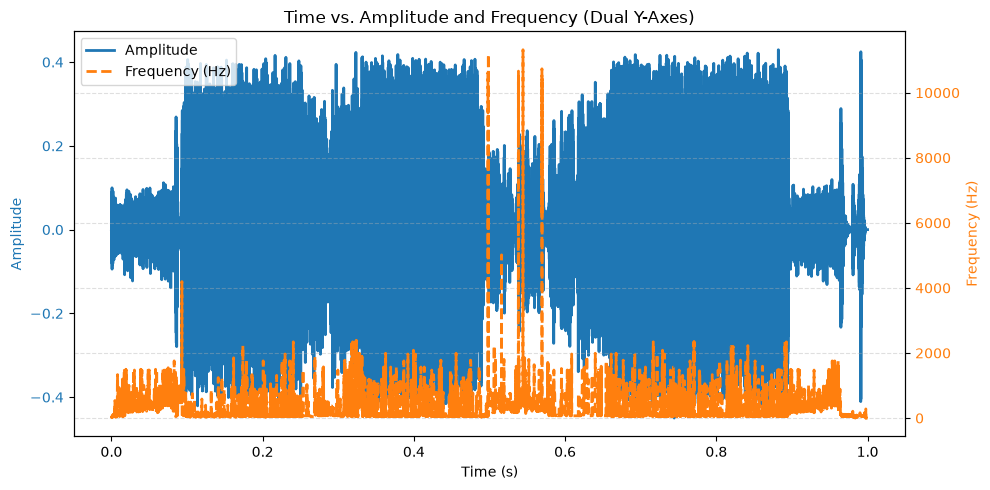

In [15]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Primary Y-Axis (Left) - Amplitude
color = '#1f77b4'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude', color=color)
l1 = ax1.plot(time, xyz_val["y"], color=color, label='Amplitude', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Secondary Y-Axis (Right) - Frequency
ax2 = ax1.twinx()  
color = '#ff7f0e'
ax2.set_ylabel('Frequency (Hz)', color=color)
l2 = ax2.plot(time, xyz_val["z"], color=color, label='Frequency (Hz)', linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# Combine legends
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Time vs. Amplitude and Frequency (Dual Y-Axes)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

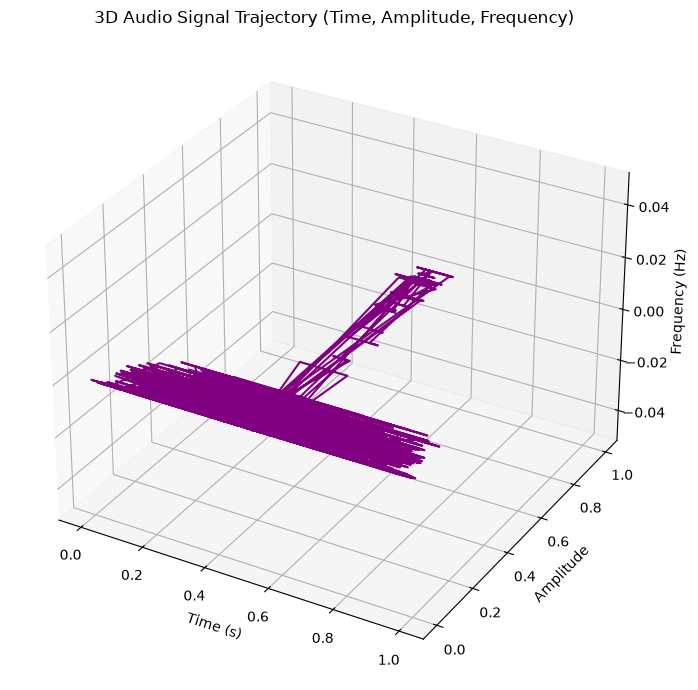

In [17]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot 3D trajectory
ax.plot(amp, freq, color='purple', linewidth=1.5)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_zlabel('Frequency (Hz)')
ax.set_title('3D Audio Signal Trajectory (Time, Amplitude, Frequency)')

plt.tight_layout()
plt.show()

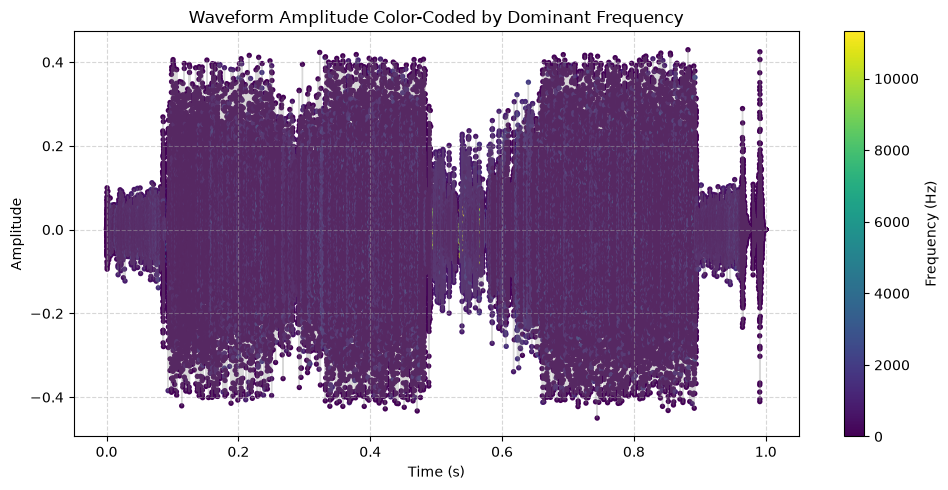

In [19]:
plt.figure(figsize=(10, 5))

# Plot waveform as a scatter with frequency color mapping
sc = plt.scatter(time, xyz_val["y"], c=xyz_val['z'], cmap='viridis', s=15, edgecolors='none')
plt.plot(time, xyz_val["y"], color='gray', alpha=0.3, linewidth=1)

cbar = plt.colorbar(sc)
cbar.set_label('Frequency (Hz)')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Waveform Amplitude Color-Coded by Dominant Frequency')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()